# VAR-X Candidate Model 3

This notebook evaluates the third candidate VAR-X specification used during baseline model selection.

The endogenous variables are:

- EUR/USD log returns (`DEXUSEU_logreturn`)
- changes in the US Economic Policy Uncertainty Index (`USEPUINDXD_diff`)

The exogenous variables are:

- VIX (`VIXCLS`)
- changes in the US 2-Year Treasury yield (`DGS2_diff`)

The model is estimated using a chronological train/test split, with the final 20 observations reserved for out-of-sample forecast evaluation. Standardisation parameters are estimated using the training sample only.

Candidate lag orders are compared using information criteria and numerical convergence. Unlike Candidate Models 1 and 2, this specification produces converged candidate models and is therefore retained for subsequent analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

from matplotlib.backends.backend_pdf import PdfPages

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.vector_ar.vecm import coint_johansen
try:
    from statsmodels.tsa.statespace.varmax import VARMAX
except ImportError:
    from statsmodels.tsa.api import VARMAX
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

In [2]:
# Configuration cell 
ENDOG_COLS = ["DEXUSEU_logreturn", "USEPUINDXD_diff"]
EXOG_COLS = ["VIXCLS", "DGS2_diff"]
N_TEST = 20
MAX_LAG = 12
SIGNIF = 0.05

In [3]:
# Function for loading and preparing data
def load_data(path, date_col="Date"):
    """Load a CSV, parse dates, set datetime index, sort chronologically."""
    df = pd.read_csv(path)
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col).sort_index()
    return df

# Function for splitting the dataframe into endogenous and exogenous variables
def split_endog_exog(df):
    """Split the loaded dataframe into endogenous and exogenous blocks per CONFIG."""
    missing = [c for c in ENDOG_COLS + EXOG_COLS if c not in df.columns]
    if missing:
        raise KeyError(f"Columns in CONFIG but not in data: {missing}")
    return df[ENDOG_COLS].copy(), df[EXOG_COLS].copy()

# Function for plotting the time series data
def plot_series(df, save_path=None):
    """Plot each column in its own panel for visual inspection."""
    n = len(df.columns)
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(8, 2.2 * n), dpi=120, squeeze=False)
    for ax, col in zip(axes.flatten(), df.columns):
        ax.plot(df.index, df[col], linewidth=1)
        ax.set_title(col, fontsize=9)
        ax.tick_params(labelsize=7)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path)
    return fig

# Function for performing pairwise Granger causality tests
# This test checks whether lagged values of one endogenous variable improve the
# prediction of another endogenous variable, beyond what the variable's own lags
# already explain.
# The output is a matrix of the minimum p-values across tested lags for each pair.

def granger_matrix(df, maxlag=MAX_LAG, test="ssr_chi2test"):
    """Pairwise Granger causality p-values. Rows = response (y), columns = predictor (x).
    Cell value = min p-value across lags 1..maxlag. Run on ENDOG columns only."""
    variables = df.columns
    mat = pd.DataFrame(np.zeros((len(variables), len(variables))),
                       columns=variables, index=variables)
    for c in mat.columns:
        for r in mat.index:
            if r == c:
                mat.loc[r, c] = np.nan
                continue
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", FutureWarning)
                res = grangercausalitytests(df[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [res[lag][0][test][1] for lag in range(1, maxlag + 1)]
            mat.loc[r, c] = np.min(p_values)
    mat.columns = [v + "_x" for v in variables]
    mat.index = [v + "_y" for v in variables]
    return mat



# Function for performing the Johansen cointegration test
# The Johansen test checks whether multiple time series share a long-run equilibrium.
# It identifies the number of cointegrating relationships among the endogenous variables.
def cointegration_test(df, alpha=SIGNIF, det_order=0, k_ar_diff=5):
    """Johansen trace test. Row 'r<=i' rejected => more than i cointegrating relations.
    Run on ENDOG columns in LEVELS (not differenced)."""
    res = coint_johansen(df, det_order, k_ar_diff)
    col = {0.90: 0, 0.95: 1, 0.99: 2}[round(1 - alpha, 2)]
    out = pd.DataFrame({
        "trace_stat": res.lr1,
        f"crit_{int((1 - alpha) * 100)}%": res.cvt[:, col],
    }, index=[f"r<={i}" for i in range(len(res.lr1))])
    out["reject"] = out["trace_stat"] > out.iloc[:, 1]
    return out

# Functions for performing the Augmented Dickey-Fuller (ADF) test
# The Augmented Dickey-Fuller test checks whether a time series has a unit root.
# The null hypothesis is that the series is non-stationary.
# A series "passes" the test when the p-value is below the significance level,
# meaning the null is rejected and the series is likely stationary.
# If the p-value is above the threshold, the series often needs differencing or
# another transformation before re-testing for stationarity.
def adf_report(series, signif=SIGNIF):
    """ADF test on one series. Null: unit root (non-stationary)."""
    stat, pvalue, nlags, nobs, crit, icbest = adfuller(series.dropna(), autolag="AIC")
    return {"variable": series.name, "adf_stat": round(stat, 4),
            "pvalue": round(pvalue, 4), "n_lags": nlags,
            "stationary": pvalue <= signif}

def run_adf_all(df, signif=SIGNIF):
    """ADF on every column; returns one summary dataframe."""
    return pd.DataFrame([adf_report(df[c], signif) for c in df.columns]).set_index("variable")



def plot_stationarity(df, save_path=None, signif=SIGNIF):
    """For each column: level (left) vs 1st difference (right),
    with the ADF p-value and verdict embedded in each panel title."""
    n = len(df.columns)
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(11, 2.4 * n), dpi=120, squeeze=False)
    diffed = df.diff()
    for i, col in enumerate(df.columns):
        for j, (data, label) in enumerate([(df[col], "level"), (diffed[col], "1st difference")]):
            p = adfuller(data.dropna(), autolag="AIC")[1]
            ax = axes[i, j]
            ax.plot(data.index, data, linewidth=0.9)
            verdict = "stationary" if p <= signif else "NON-stationary"
            ax.set_title(f"{col} ({label}) - ADF p={p:.4f} [{verdict}]", fontsize=8)
            ax.tick_params(labelsize=6)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path)
    return fig

# Functions for differencing until stationarity
# NOTE: The following section contains functions to repeatedly
# difference the entire dataframe until all series pass the ADF
# stationarity test. These functions operate on the whole frame
# (not column-by-column) to keep a consistent order of integration
# across variables for multivariate modelling.
# Be cautious: this may over-difference already-stationary series (n_diffs > 2 may be risky).


def _all_stationary(df, signif=SIGNIF):
    """True if every column passes the ADF test."""
    return all(adfuller(df[c].dropna(), autolag="AIC")[1] <= signif
               for c in df.columns)

def difference_until_stationary(df, signif=SIGNIF, max_diffs=2):
    """Difference the WHOLE frame until all columns are stationary.
    Returns (differenced_df, n_diffs). n_diffs is needed later to invert forecasts."""
    n_diffs = 0
    out = df.copy()
    while not _all_stationary(out, signif) and n_diffs < max_diffs:
        out = out.diff().dropna()
        n_diffs += 1
    if not _all_stationary(out, signif):
        raise ValueError(f"Still non-stationary after {max_diffs} differences - inspect the data.")
    return out, n_diffs


# Drawbacks of differencing already-stationary variables:
# - Over-differencing (applying differences to series that are already
# stationary) can remove meaningful long-run information and introduce
# moving-average structure, complicating model identification.
# - It can increase noise and reduce signal-to-noise ratio, degrading
# forecasting performance and interpretability.
# - Differencing changes the series' variance/stochastic properties and
# may necessitate additional modelling choices (e.g. extra lags, MA
# terms) to capture the induced dynamics.
# - Because this function diffs the whole frame, a single non-stationary
# series forces differencing of all variables; this may be undesirable if
# some variables are already stationary and should remain in levels.

# Consider alternatives when appropriate:
# - Test and difference each series individually, tracking orders of
# integration per variable.

# Function for splitting the dataset into training and testing sets
def train_test_split_ts(endog, exog, n_test=N_TEST):
    """Chronological split - LAST n_test rows held out, never random.
    Aligns endog and exog to their common index first, so unequal
    differencing upstream can't silently desynchronise the frames.
    Returns (endog_train, endog_test, exog_train, exog_test)."""
    common = endog.index.intersection(exog.index)
    endog, exog = endog.loc[common], exog.loc[common]
    return (endog.iloc[:-n_test], endog.iloc[-n_test:],
            exog.iloc[:-n_test], exog.iloc[-n_test:])


# Function for selecting the optimal lag order for VAR-X model
def select_lag_order(endog, exog=None, max_lag=6):
    """Fit VARMAX(p, 0) for p = 1..max_lag; return AIC/BIC/HQIC per lag.
    Why VARMAX not VAR: plain statsmodels VAR has no exog support, and
      lag selection must happen in the SAME model class you'll estimate.
    Watch for: converged=False rows - their information criteria are
      untrustworthy; also MLE runtime grows fast with k and p."""
    rows = []
    for p in range(1, max_lag + 1):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            res = VARMAX(endog, exog=exog, order=(p, 0)).fit(disp=False)
        rows.append({"lag": p, "aic": res.aic, "bic": res.bic, "hqic": res.hqic,
                     "converged": res.mle_retvals.get("converged", None)})
    return pd.DataFrame(rows).set_index("lag")


def plot_lag_selection(lag_tbl, save_path=None):
    """AIC/BIC/HQIC vs lag order; circled point = each criterion's minimum."""
    fig, ax = plt.subplots(figsize=(7, 4), dpi=120)
    for crit in ["aic", "bic", "hqic"]:
        ax.plot(lag_tbl.index, lag_tbl[crit], marker="o", label=crit.upper())
        best = lag_tbl[crit].idxmin()
        ax.scatter([best], [lag_tbl.loc[best, crit]], s=150, facecolors="none",
                   edgecolors="black", zorder=5)
    ax.set_xlabel("lag order p"); ax.set_ylabel("criterion")
    ax.set_xticks(lag_tbl.index)
    ax.legend(); ax.set_title("Lag order selection (circled = minimum)")
    plt.tight_layout()
    if save_path: fig.savefig(save_path)
    return fig

def plot_cross_correlations(endog, exog=None, max_lag=10, save_path=None):
    """Grid of corr(predictor(t-k), response(t)) for k = 0..max_lag.
    Rows = responses (endog), columns = predictors (endog + exog).
    Dashed lines: approximate 95% band (+/- 2/sqrt(n)).
    Shows WHERE relationships live in lag-space; the VAR still uses one system-wide p."""
    df = endog if exog is None else pd.concat([endog, exog], axis=1).dropna()
    responses, predictors = endog.columns, df.columns
    nr, npred = len(responses), len(predictors)
    fig, axes = plt.subplots(nr, npred, figsize=(2.6 * npred, 2.2 * nr),
                             dpi=120, squeeze=False)
    ci = 2 / np.sqrt(len(df))
    for i, r in enumerate(responses):
        for j, p in enumerate(predictors):
            ccf_vals = [df[r].corr(df[p].shift(k)) for k in range(max_lag + 1)]
            ax = axes[i, j]
            ax.bar(range(max_lag + 1), ccf_vals, width=0.6)
            ax.axhline(ci, color="gray", ls="--", lw=0.7)
            ax.axhline(-ci, color="gray", ls="--", lw=0.7)
            ax.axhline(0, color="black", lw=0.7)
            ax.set_title(f"{p}(t-k) -> {r}(t)", fontsize=7)
            ax.tick_params(labelsize=6); ax.set_ylim(-1, 1)
    plt.tight_layout()
    if save_path: fig.savefig(save_path)
    return fig

# Function for fitting the VAR-X model using maximum likelihood estimation
def fit_varx(endog, exog=None, p=1, verbose=False):
    """Fit the VAR-X: VARMAX(p, 0) with exogenous regressors, by MLE.
    Warnings deliberately NOT suppressed here - this is the model you
    will interpret, so convergence complaints must be visible.
    verbose=True prints the full coefficient summary."""
    model = VARMAX(endog, exog=exog, order=(p, 0))
    results = model.fit(disp=False)
    if verbose:
        print(results.summary())
    return results

# Function for performing residual diagnostics on the fitted model
def residual_diagnostics(results, endog_cols, lb_lags=5):
    """Per-equation residual checks after fitting.
    durbin_watson: ~2 = no lag-1 autocorrelation (<1.5 positive, >2.5 negative).
    lb_pvalue: Ljung-Box joint test over lags 1..lb_lags; LOW p = leftover
      autocorrelation = model underspecified (raise p or rethink variables)."""
    resid = pd.DataFrame(results.resid, columns=endog_cols)
    dw = durbin_watson(resid.values)
    lb_p = [acorr_ljungbox(resid[c], lags=[lb_lags], return_df=True)["lb_pvalue"].iloc[0]
            for c in endog_cols]
    out = pd.DataFrame({"durbin_watson": np.round(dw, 3),
                        "lb_pvalue": np.round(lb_p, 4)}, index=endog_cols)
    out["dw_verdict"] = pd.cut(out["durbin_watson"], bins=[0, 1.5, 2.5, 4],
                               labels=["positive autocorr", "ok", "negative autocorr"])
    return out

# Functions for generating a PDF report of the model results and diagnostics
def _df_to_page(pdf, df, title, fontsize=8):
    """Render a dataframe as a table on its own A4 page of the PDF."""
    fig, ax = plt.subplots(figsize=(8.27, 11.69), dpi=120)
    ax.axis("off")
    ax.set_title(title, fontsize=12, pad=20)
    tbl = ax.table(cellText=df.round(4).astype(str).values,
                   rowLabels=df.index, colLabels=df.columns,
                   loc="upper center", cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(fontsize); tbl.scale(1, 1.3)
    pdf.savefig(fig); plt.close(fig)

# function for generating a multi-page PDF report of the model results and diagnostics
def generate_report(path, results, endog, exog, lag_tbl=None, p=None,
                    adf_levels=None, adf_transformed=None, diag=None,
                    n_diffs=None, extra_figs=None):
    """Write a multi-page PDF: model equation + estimation summary,
    coefficient table, then whichever diagnostic tables/figures are passed.
    All table arguments optional - the report grows with the pipeline."""
    k = len(endog.columns)
    m = len(exog.columns) if exog is not None else 0
    p = p if p is not None else results.model.k_ar
    with PdfPages(path) as pdf:
        # Page 1: equation + summary
        fig, ax = plt.subplots(figsize=(8.27, 11.69), dpi=120)
        ax.axis("off")
        y = 0.95
        ax.text(0.5, y, "VAR-X Model Report", ha="center", fontsize=18, weight="bold"); y -= 0.06
        ax.text(0.5, y, f"Generated {pd.Timestamp.now():%Y-%m-%d %H:%M}", ha="center", fontsize=9); y -= 0.07
        ax.text(0.05, y, "Model equation:", fontsize=11, weight="bold"); y -= 0.06
        ax.text(0.5, y, r"$y_t = c + \sum_{i=1}^{p} A_i \, y_{t-i} + B\, x_t + u_t$",
                ha="center", fontsize=15); y -= 0.05
        ax.text(0.5, y, rf"$y_t \in \mathbb{{R}}^{{{k}}}$ (endogenous),  "
                        rf"$x_t \in \mathbb{{R}}^{{{m}}}$ (exogenous),  $p = {p}$",
                ha="center", fontsize=11); y -= 0.07
        ax.text(0.05, y, "Endogenous: " + ", ".join(endog.columns), fontsize=10); y -= 0.04
        ax.text(0.05, y, "Exogenous:  " + (", ".join(exog.columns) if m else "(none)"), fontsize=10); y -= 0.04
        if n_diffs is not None:
            ax.text(0.05, y, f"Differencing applied to endog: {n_diffs}x", fontsize=10); y -= 0.04
        ax.text(0.05, y, f"Observations: {results.nobs}   AIC: {results.aic:.2f}   "
                         f"BIC: {results.bic:.2f}   Converged: "
                         f"{results.mle_retvals.get('converged', '?')}", fontsize=10)
        pdf.savefig(fig); plt.close(fig)

        # Page 2: coefficients with inference
        coef = pd.DataFrame({"coef": results.params, "std_err": results.bse,
                             "pvalue": results.pvalues})
        _df_to_page(pdf, coef, "Estimated coefficients "
                    "(L{lag}.{predictor}.{response} / beta.{exog}.{response})")

        if adf_levels is not None:
            _df_to_page(pdf, adf_levels, "ADF tests - levels")
        if adf_transformed is not None:
            _df_to_page(pdf, adf_transformed, "ADF tests - transformed (as modelled)")
        if lag_tbl is not None:
            _df_to_page(pdf, lag_tbl, "Lag order selection (information criteria)")
        if diag is not None:
            _df_to_page(pdf, diag, "Residual diagnostics")
        if extra_figs:
            for f in extra_figs:
                pdf.savefig(f)
    return path


def forecast_varx(results, steps, exog_future=None):
    """Forecast `steps` ahead. THE VAR-X CATCH: exog_future must contain
    the exogenous values for those future dates - shape (steps, n_exog).
    In backtesting these come from the held-out test set (legitimate: we
    evaluate 'given the controls, did geopolitical signals add predictive
    power?'). In LIVE forecasting they must be projected or scenario-set -
    using realized future values there is look-ahead bias.
    Returns (mean_forecast, conf_int) as dataframes."""
    fc = results.get_forecast(steps=steps, exog=exog_future)
    return fc.predicted_mean, fc.conf_int()


def invert_differencing(levels_train, forecast_diffed, n_diffs):
    """Convert a forecast made in differenced space back to LEVELS.
    levels_train: the ORIGINAL (pre-differencing) endog training frame.
    forecast_diffed: the forecast from forecast_varx (differenced space).
    n_diffs: the counter returned by difference_until_stationary.
    Works by re-anchoring on the last observed value at each differencing
    depth and cumulatively summing - once per diff, deepest first."""
    if n_diffs == 0:
        return forecast_diffed.copy()
    fc = forecast_diffed.copy()
    for d in range(n_diffs, 0, -1):
        anchor = levels_train.copy()
        for _ in range(d - 1):
            anchor = anchor.diff().dropna()
        fc = anchor.iloc[-1] + fc.cumsum()
    return fc

def forecast_accuracy(forecast, actual):
    """Per-variable forecast metrics. Aligns frames on their common index first.
    rmse_vs_naive is the headline: < 1 means the model beats a no-change
    (random walk) forecast; > 1 means it doesn't. NaN where undefined
    (MAPE with ~zero actuals; naive ratio with constant actuals)."""
    f, a = forecast.align(actual, join="inner")
    rows = {}
    for c in f.columns:
        e = f[c] - a[c]
        denom_ok = (a[c].abs() > 1e-8)
        mape = (e[denom_ok].abs() / a[c][denom_ok].abs()).mean() if denom_ok.any() else np.nan
        naive_rmse = np.sqrt(((a[c] - a[c].shift(1)).dropna() ** 2).mean())
        rows[c] = {
            "rmse": np.sqrt((e ** 2).mean()),
            "mae": e.abs().mean(),
            "me": e.mean(),
            "mape": mape,
            "corr": f[c].corr(a[c]),
            "rmse_vs_naive": (np.sqrt((e ** 2).mean()) / naive_rmse)
                              if naive_rmse > 1e-12 else np.nan,
        }
    return pd.DataFrame(rows).T.round(4)


def plot_forecast_vs_actual(fc_mean, actual, fc_ci=None, train_tail=None, save_path=None):
    """One panel per variable: recent training data (gray), actuals (black),
    forecast (dashed blue), 95% CI band (shaded). Works in either space -
    pass differenced or level frames consistently, never mixed."""
    cols = fc_mean.columns
    n = len(cols)
    fig, axes = plt.subplots(n, 1, figsize=(8, 2.6 * n), dpi=120, squeeze=False)
    for ax, c in zip(axes.flatten(), cols):
        if train_tail is not None:
            ax.plot(train_tail.index, train_tail[c], color="gray", lw=0.9, label="train (tail)")
        ax.plot(actual.index, actual[c], color="black", lw=1.1, label="actual")
        ax.plot(fc_mean.index, fc_mean[c], color="tab:blue", lw=1.1, ls="--", label="forecast")
        if fc_ci is not None:
            ax.fill_between(fc_mean.index, fc_ci[f"lower {c}"], fc_ci[f"upper {c}"],
                            alpha=0.18, color="tab:blue", label="95% CI")
        ax.set_title(c, fontsize=9)
        ax.legend(fontsize=6)
        ax.tick_params(labelsize=6)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path)
    return fig

In [4]:
# Loading the data
df = load_data(
    r"C:\Users\franc\OneDrive\Geop-Model\data\processed\macro_processed.csv",
    date_col="observation_date"
)

In [5]:
# Confirm stationarity of transformed datasets
adf_results = run_adf_all(df)
print(adf_results)

                   adf_stat  pvalue  n_lags  stationary
variable                                               
DEXUSEU_logreturn  -21.4143     0.0       5        True
DGS2_diff           -9.9390     0.0      17        True
USEPUINDXD_diff    -12.1823     0.0      23        True
VIXCLS              -5.2217     0.0       9        True


In [6]:
# Split variables into endogenous and exogenous blocks

endog, exog = split_endog_exog(df)

print("Endogenous variables:")
print(endog.columns.tolist())

print("\nExogenous variables:")
print(exog.columns.tolist())

Endogenous variables:
['DEXUSEU_logreturn', 'USEPUINDXD_diff']

Exogenous variables:
['VIXCLS', 'DGS2_diff']


In [7]:
# Create complete modelling sample (no NaN's from dates where one or more variables were not retrieved)

model_df = pd.concat([endog, exog], axis=1).dropna()

endog_model = model_df[ENDOG_COLS]
exog_model = model_df[EXOG_COLS]

print("Complete modelling sample:", model_df.shape)
print(model_df.isna().sum())

Complete modelling sample: (2376, 4)
DEXUSEU_logreturn    0
USEPUINDXD_diff      0
VIXCLS               0
DGS2_diff            0
dtype: int64


In [8]:
# Align and split into training and test sets

etr, ete, xtr, xte = train_test_split_ts(
    endog_model,
    exog_model
)

print("Endog train:", etr.shape)
print("Endog test:", ete.shape)
print("Exog train:", xtr.shape)
print("Exog test:", xte.shape)

Endog train: (2356, 2)
Endog test: (20, 2)
Exog train: (2356, 2)
Exog test: (20, 2)


In [9]:
# Standardise variables using training-set statistics only

endog_mean = etr.mean()
endog_std = etr.std()

exog_mean = xtr.mean()
exog_std = xtr.std()

etr_scaled = (etr - endog_mean) / endog_std
ete_scaled = (ete - endog_mean) / endog_std

xtr_scaled = (xtr - exog_mean) / exog_std
xte_scaled = (xte - exog_mean) / exog_std

## Lag Selection and Convergence

Candidate lag orders from 1 to 3 are evaluated using the Akaike Information Criterion (AIC), Bayesian Information Criterion (BIC), and Hannan-Quinn Information Criterion (HQIC), together with numerical convergence.

For Model 3, the lag-2 and lag-3 specifications converge successfully, unlike the preceding candidate models. The final lag order is selected from the converged specifications using the information-criterion results below.

This provides a numerically viable VAR-X specification for subsequent diagnostic and forecasting evaluation.

In [10]:
# Lag selection

lag_tbl = select_lag_order(etr, xtr, max_lag=3)

print(lag_tbl.round(2))

         aic      bic     hqic  converged
lag                                      
1    8539.66  8614.60  8566.95      False
2    8293.35  8391.35  8329.04       True
3    8199.24  8320.30  8243.32       True


In [11]:
# Select the preferred converged lag using AIC

converged_lags = lag_tbl[lag_tbl["converged"]]

p_star = int(converged_lags["aic"].idxmin())

print("Selected lag:", p_star)

Selected lag: 3


Lag-selection and cross-correlation plots saved.


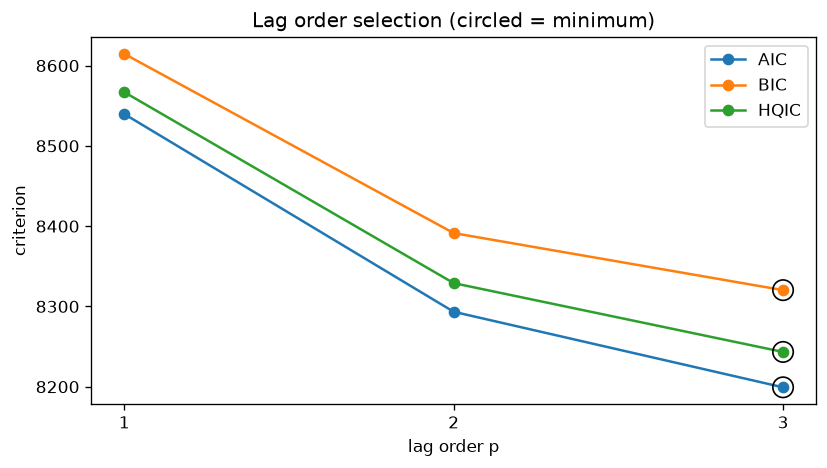

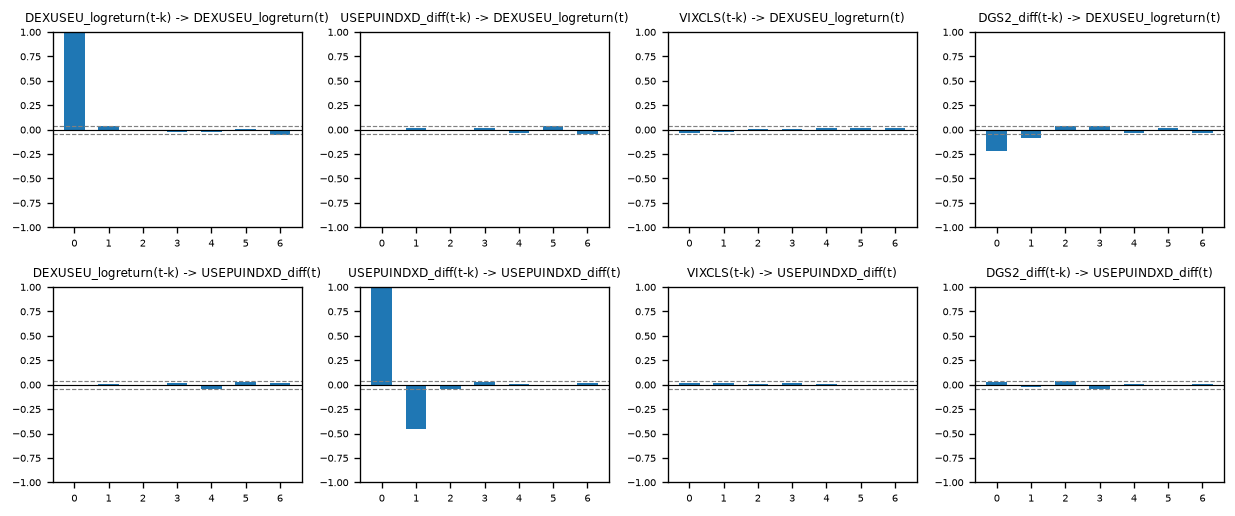

In [12]:
# Plot lag-selection criteria and cross-correlations

plot_lag_selection(
    lag_tbl,
    save_path="try3_lag_selection.png"
)

plot_cross_correlations(
    etr,
    xtr,
    max_lag=6,
    save_path="try3_ccf.png"
)

print("Lag-selection and cross-correlation plots saved.")

In [13]:
# Fit the selected model using STANDARDISED training data

varx_res_scaled = fit_varx(
    etr_scaled,
    xtr_scaled,
    p=p_star,
    verbose=True
)

print(
    f"Scaled VAR-X({p_star}) fitted",
    "| converged:",
    varx_res_scaled.mle_retvals["converged"],
    "| parameters:",
    len(varx_res_scaled.params)
)

c:\Users\franc\OneDrive\Geop-Model\Geop-Model-main\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                      Statespace Model Results                                      
Dep. Variable:     ['DEXUSEU_logreturn', 'USEPUINDXD_diff']   No. Observations:                 2356
Model:                                              VARX(3)   Log Likelihood               -6171.251
                                                + intercept   AIC                          12384.501
Date:                                      Sun, 09 Aug 2026   BIC                          12505.561
Time:                                              12:05:06   HQIC                         12428.584
Sample:                                                   0                                         
                                                     - 2356                                         
Covariance Type:                                        opg                                         
Ljung-Box (L1) (Q):             0.97, 1.90   Jarque-Bera (JB):     304.71, 19297.09
Prob(Q)

## Model Diagnostics

Following estimation of the selected VAR-X specification, residual diagnostics are examined to assess whether the fitted model provides an adequate representation of the endogenous dynamics.

These diagnostics complement the convergence and information-criterion results and are considered alongside out-of-sample forecasting performance when evaluating the suitability of Model 3 as the baseline specification.

In [14]:
# Residual diagnostics

diag_scaled = residual_diagnostics(
    varx_res_scaled,
    ENDOG_COLS
)


print(diag_scaled)

                   durbin_watson  lb_pvalue dw_verdict
DEXUSEU_logreturn          2.040     0.5978         ok
USEPUINDXD_diff            2.055     0.0000         ok


'model3_report.pdf'

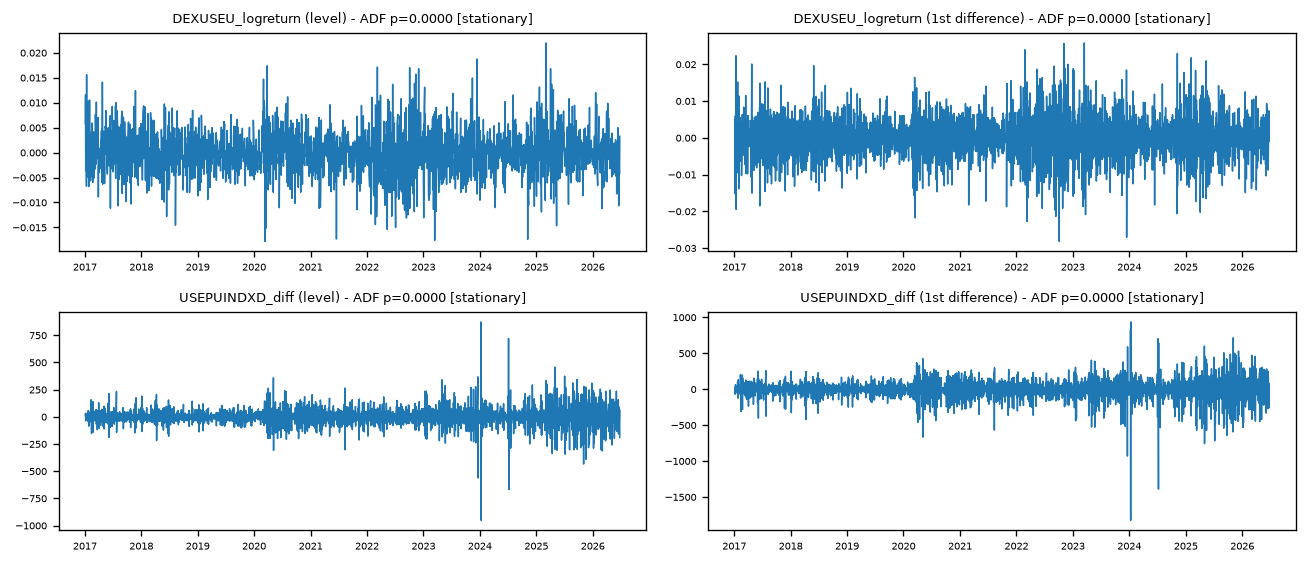

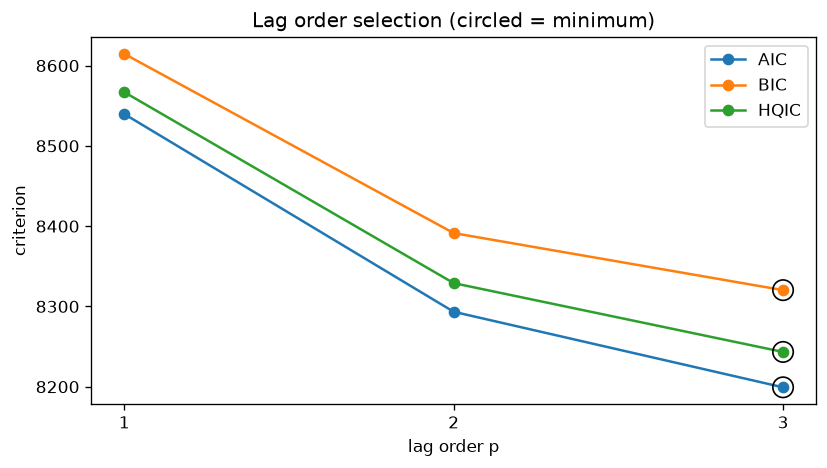

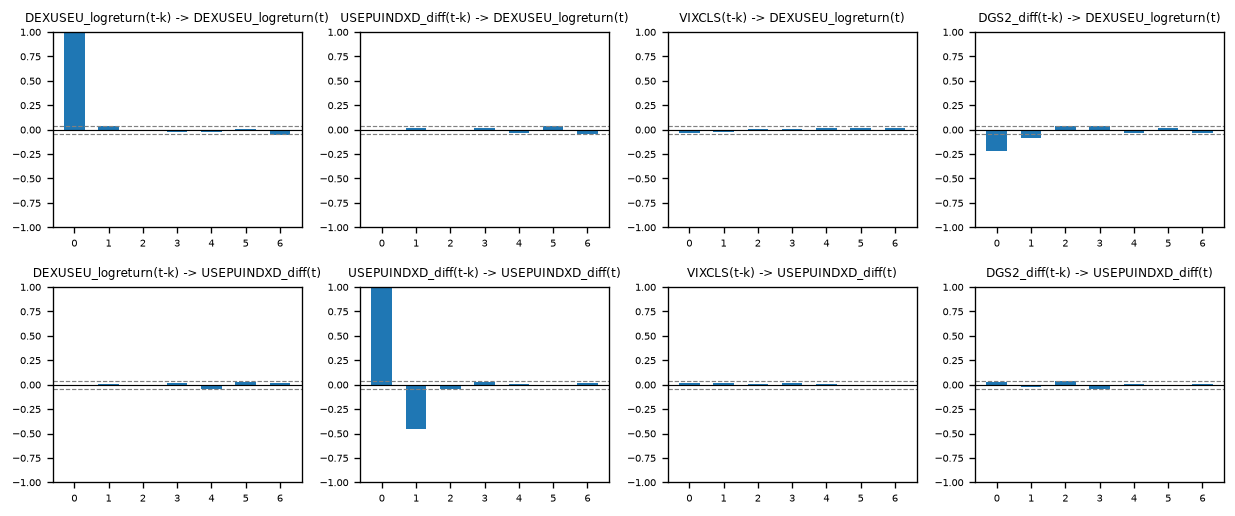

In [15]:
# 14. PDF report

figs = [
    plot_stationarity(etr),
    plot_lag_selection(lag_tbl),
    plot_cross_correlations(etr, xtr, max_lag=6)
]

generate_report(
    path="model3_report.pdf",
    results=varx_res_scaled,
    endog=etr_scaled,
    exog=xtr_scaled,
    lag_tbl=lag_tbl,
    p=p_star,
    diag=diag_scaled,
    extra_figs=figs
)

## Out-of-Sample Forecast Evaluation

The fitted Model 3 specification is evaluated on the final 20 observations that were excluded from model estimation.

Forecast accuracy is first assessed in the transformed/modelled space for EUR/USD log returns and changes in Economic Policy Uncertainty. EUR/USD forecasts are subsequently reconstructed into spot-rate levels to provide an economically interpretable comparison between predicted and observed exchange-rate movements.

These results are used alongside convergence, model diagnostics and information criteria to assess Model 3 relative to the alternative baseline VAR-X specifications.

In [16]:
# Forecast the held-out test period

fc_mean_scaled, fc_ci_scaled = forecast_varx(
    varx_res_scaled,
    steps=N_TEST,
    exog_future=xte_scaled
)

print("Forecast shape:", fc_mean_scaled.shape)
print(
    "Forecast period:",
    fc_mean_scaled.index.min(),
    "to",
    fc_mean_scaled.index.max()
)

Forecast shape: (20, 2)
Forecast period: 2356 to 2375


c:\Users\franc\OneDrive\Geop-Model\Geop-Model-main\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\franc\OneDrive\Geop-Model\Geop-Model-main\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [17]:
# Replace integer forecast index with the actual test dates

fc_mean_scaled.index = ete.index
fc_ci_scaled.index = ete.index

fc_mean = fc_mean_scaled * endog_std + endog_mean
fc_mean.index = ete.index

In [18]:
# Evaluate forecast accuracy

acc_transformed = forecast_accuracy(
    fc_mean,
    ete
)

print("Forecast accuracy in modelled space:")
print(acc_transformed)

Forecast accuracy in modelled space:
                       rmse      mae       me    mape    corr  rmse_vs_naive
DEXUSEU_logreturn    0.0020   0.0016  -0.0001  1.2689  0.6178         0.4981
USEPUINDXD_diff    146.9326  88.6914 -19.1842  1.2493 -0.0747         0.8568


In [19]:
# Load original EUR/USD and EPU level series

eurusd_raw = load_data(
    r"C:\Users\franc\OneDrive\Geop-Model\data\raw\DEXUSEU.csv",
    date_col="observation_date"
)

usepu_raw = load_data(
    r"C:\Users\franc\OneDrive\Geop-Model\data\raw\USEPUINDXD.csv",
    date_col="observation_date"
)

print("EUR/USD raw columns:", eurusd_raw.columns.tolist())
print("EPU raw columns:", usepu_raw.columns.tolist())

display(eurusd_raw.head())
display(usepu_raw.head())

EUR/USD raw columns: ['DEXUSEU']
EPU raw columns: ['USEPUINDXD']


,DEXUSEU
observation_date,
2017-01-03,1.0416
2017-01-04,1.0476
2017-01-05,1.0598
2017-01-06,1.0560
2017-01-09,1.0576


,USEPUINDXD
observation_date,
2017-01-01,235.10
2017-01-02,242.04
2017-01-03,89.85
2017-01-04,101.99
2017-01-05,134.47


In [20]:
# Extract and align original level series

eurusd_levels = eurusd_raw["DEXUSEU"].dropna()
usepu_levels = usepu_raw["USEPUINDXD"].dropna()

forecast_dates = ete.index
forecast_start = forecast_dates[0]

# Last observed levels before the test period
last_eurusd_level = eurusd_levels.loc[
    eurusd_levels.index < forecast_start
].iloc[-1]

last_usepu_level = usepu_levels.loc[
    usepu_levels.index < forecast_start
].iloc[-1]

print("Forecast starts:", forecast_start)
print("Last training EUR/USD level:", last_eurusd_level)
print("Last training EPU level:", last_usepu_level)

Forecast starts: 2026-06-26 00:00:00
Last training EUR/USD level: 1.1385
Last training EPU level: 273.74


In [21]:
# Convert transformed forecasts back into original levels

fc_levels = pd.DataFrame(index=fc_mean.index)

# EUR/USD log returns -> EUR/USD spot level
fc_levels["DEXUSEU"] = (
    last_eurusd_level
    * np.exp(fc_mean["DEXUSEU_logreturn"].cumsum())
)

# EPU first differences -> EPU level
fc_levels["USEPUINDXD"] = (
    last_usepu_level
    + fc_mean["USEPUINDXD_diff"].cumsum()
)

display(fc_levels.head())

,DEXUSEU,USEPUINDXD
observation_date,,
2026-06-26,1.139035,366.492173
2026-06-29,1.138706,375.135998
2026-06-30,1.137784,367.722027
2026-07-01,1.137388,349.468484
2026-07-02,1.138124,361.554373


In [22]:
# Actual original levels over the held-out test period

actual_levels = pd.DataFrame(index=forecast_dates)

actual_levels["DEXUSEU"] = eurusd_levels.reindex(
    forecast_dates
)

actual_levels["USEPUINDXD"] = usepu_levels.reindex(
    forecast_dates
)

print("Missing actual level values:")
print(actual_levels.isna().sum())

display(actual_levels.head())

Missing actual level values:
DEXUSEU       0
USEPUINDXD    0
dtype: int64


,DEXUSEU,USEPUINDXD
observation_date,,
2026-06-26,1.1403,252.68
2026-06-29,1.1425,206.62
2026-06-30,1.1417,333.20
2026-07-01,1.1384,208.64
2026-07-02,1.1448,173.11


In [23]:
# Evaluate forecast accuracy in original level space

level_mask = actual_levels.notna().all(axis=1)

acc_levels = forecast_accuracy(
    fc_levels.loc[level_mask],
    actual_levels.loc[level_mask]
)

print("Forecast accuracy in original level space:")
print(acc_levels)

Forecast accuracy in original level space:
                rmse       mae       me    mape    corr  rmse_vs_naive
DEXUSEU       0.0042    0.0039  -0.0039  0.0034  0.7206         1.5646
USEPUINDXD  145.1180  117.9194  75.3492  0.4917 -0.1404         0.9795


Forecast plots saved.


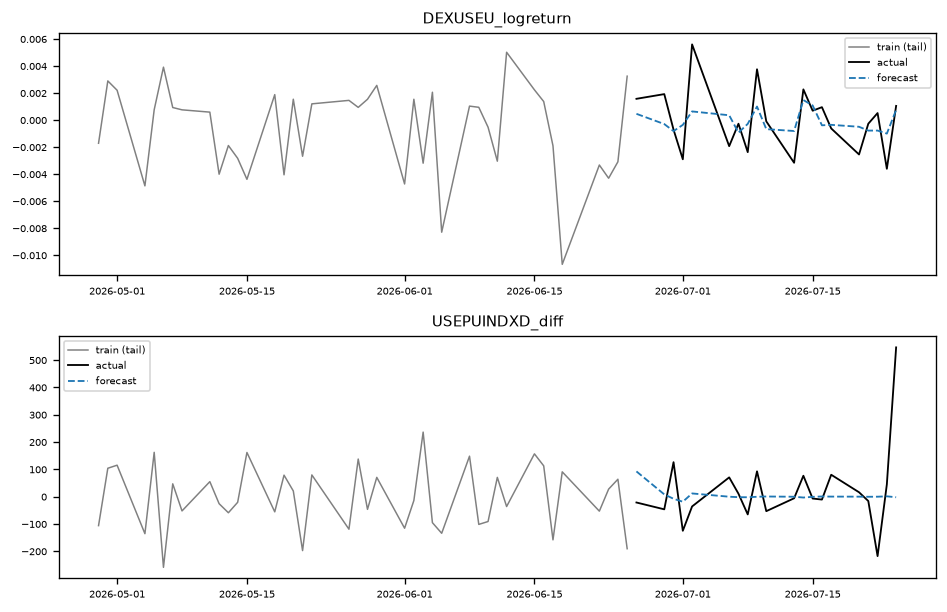

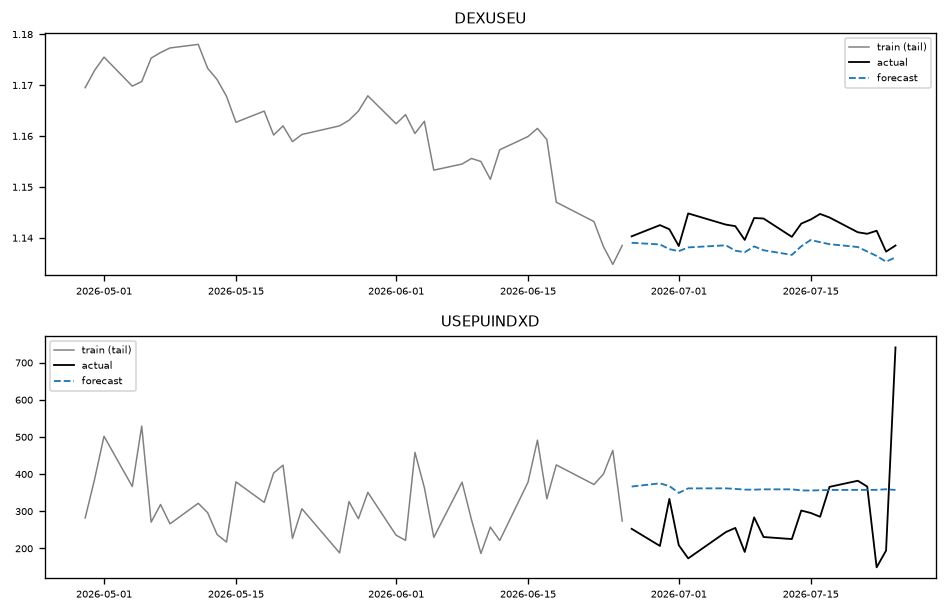

In [24]:
# Plot transformed-space forecasts

plot_forecast_vs_actual(
    fc_mean,
    ete,
    fc_ci=None,
    train_tail=etr.iloc[-40:],
    save_path="model3_forecast_transformed.png"
)

# Build a short level-space training tail for plotting
level_train_tail = pd.DataFrame(index=etr.index[-40:])

level_train_tail["DEXUSEU"] = eurusd_levels.reindex(
    level_train_tail.index
)

level_train_tail["USEPUINDXD"] = usepu_levels.reindex(
    level_train_tail.index
)

# Plot original-level forecasts

plot_forecast_vs_actual(
    fc_levels.loc[level_mask],
    actual_levels.loc[level_mask],
    fc_ci=None,
    train_tail=level_train_tail,
    save_path="model3_forecast_levels.png"
)

print("Forecast plots saved.")

In [25]:
# Validate the inverse transformations using ACTUAL test observations

actual_reconstructed = pd.DataFrame(index=ete.index)

# Reconstruct EUR/USD levels from the actual test-period log returns
actual_reconstructed["DEXUSEU"] = (
    last_eurusd_level
    * np.exp(ete["DEXUSEU_logreturn"].cumsum())
)

# Reconstruct EPU levels from the actual test-period first differences
actual_reconstructed["USEPUINDXD"] = (
    last_usepu_level
    + ete["USEPUINDXD_diff"].cumsum()
)

# Compare reconstructed actuals with raw actual levels
round_trip_check = pd.DataFrame(index=ete.index)

round_trip_check["DEXUSEU_raw"] = actual_levels["DEXUSEU"]
round_trip_check["DEXUSEU_reconstructed"] = actual_reconstructed["DEXUSEU"]
round_trip_check["DEXUSEU_error"] = (
    round_trip_check["DEXUSEU_reconstructed"]
    - round_trip_check["DEXUSEU_raw"]
)

round_trip_check["USEPU_raw"] = actual_levels["USEPUINDXD"]
round_trip_check["USEPU_reconstructed"] = actual_reconstructed["USEPUINDXD"]
round_trip_check["USEPU_error"] = (
    round_trip_check["USEPU_reconstructed"]
    - round_trip_check["USEPU_raw"]
)

display(round_trip_check)

print(
    "Maximum EUR/USD reconstruction error:",
    round_trip_check["DEXUSEU_error"].abs().max()
)

print(
    "Maximum EPU reconstruction error:",
    round_trip_check["USEPU_error"].abs().max()
)

,DEXUSEU_raw,DEXUSEU_reconstructed,DEXUSEU_error,USEPU_raw,USEPU_reconstructed,USEPU_error
observation_date,,,,,,
2026-06-26,1.1403,1.1403,0.000000e+00,252.68,252.68,0.0
2026-06-29,1.1425,1.1425,0.000000e+00,206.62,206.62,0.0
2026-06-30,1.1417,1.1417,-2.220446e-16,333.20,333.20,0.0
2026-07-01,1.1384,1.1384,0.000000e+00,208.64,208.64,0.0
2026-07-02,1.1448,1.1448,0.000000e+00,173.11,173.11,0.0
2026-07-06,1.1426,1.1426,0.000000e+00,243.98,243.98,0.0
2026-07-07,1.1423,1.1423,0.000000e+00,255.15,255.15,0.0
2026-07-08,1.1396,1.1396,0.000000e+00,190.46,190.46,0.0
2026-07-09,1.1439,1.1439,-2.220446e-16,283.47,283.47,0.0


Maximum EUR/USD reconstruction error: 2.220446049250313e-16
Maximum EPU reconstruction error: 0.0


In [26]:
print("Model 3 observations:", len(model_df))
print("Model 3 start date:", model_df.index.min())
print("Model 3 end date:", model_df.index.max())

Model 3 observations: 2376
Model 3 start date: 2017-01-04 00:00:00
Model 3 end date: 2026-07-24 00:00:00


## Summary

Model 3 specifies EUR/USD log returns and changes in US Economic Policy Uncertainty as endogenous variables, with VIX and changes in the US 2-Year Treasury yield included as exogenous controls.

Unlike Candidate Models 1 and 2, Model 3 produces converged lag specifications, allowing meaningful diagnostic and out-of-sample forecast evaluation. Its combination of numerical convergence, model diagnostics, forecasting performance and relative parsimony supports its selection as the preferred baseline specification.

Model 3 therefore provides the baseline VAR-X structure used in the subsequent geopolitical-risk analysis, where the LLM-derived geopolitical indices are introduced and alternative representations of geopolitical information are compared.